# Build sentence positive or negative recognition with bag of words model

## Importing the libraries

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## data preprocessing

### Importing the dataset

In [58]:
dataset = pd.read_csv('Restaurant_Reviews.tsv', delimiter='\t', quoting=3)
dataset.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [59]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  1000 non-null   object
 1   Liked   1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


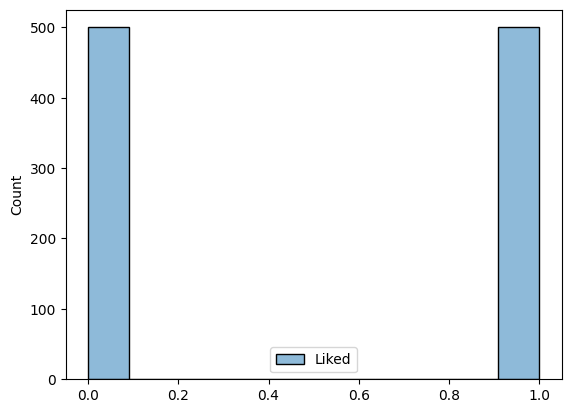

In [60]:
import seaborn as sns
sns.histplot(dataset)
plt.show()

### Cleaning the text

In [61]:
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
corpus = []

for i in range(0, 1000):
  review = re.sub('[^a-zA-Z]', ' ', dataset['Review'][i])
  review = review.lower()
  review = review.split()
  ps = PorterStemmer()
  all_stopwords = stopwords.words('english')
  all_stopwords.remove('not')
  review = [ps.stem(word) for word in review if not word in set(all_stopwords)]
  review = ' '.join(review)
  corpus.append(review)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [62]:
corpus[::50]

['wow love place',
 'order duck rare pink tender insid nice char outsid',
 'server fantast found wife love roast garlic bone marrow ad extra meal anoth marrow go',
 'fianc came middl day greet seat right away',
 'heard good thing place exceed everi hope could dream',
 'owner realli great peopl',
 'good beer drink select good food select',
 'sat anoth ten minut final gave left',
 'one simpli disappoint',
 'think go back anytim soon',
 'also tast mom multi grain pumpkin pancak pecan butter amaz fluffi delici',
 'realli recommend place go wrong donut place',
 'miss wish one philadelphia',
 'disappoint order big bay plater',
 'chip came drip greas mostli not edibl',
 'got enjoy seafood salad fabul vinegrett',
 'super pissd',
 'potato great biscuit',
 'spend money elsewher',
 'busi know']

### Creating the Bag Of Words model

In [63]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features=1500)
x = cv.fit_transform(corpus).toarray()
y = dataset.iloc[:, 1].values

In [64]:
x.shape

(1000, 1500)

In [65]:
(x[5] == 1).sum()

np.int64(5)

### Spliting data into train set and test set

In [66]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

## Build the models

In [67]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

forest_model = RandomForestClassifier(random_state=0)
logistic_model = LogisticRegression()
naive_model = GaussianNB()

forest_model.fit(x_train, y_train)
logistic_model.fit(x_train, y_train)
naive_model.fit(x_train, y_train)

GaussianNB()

## Predicting with models

In [68]:
forest_y = forest_model.predict(x_test)
logistic_y = logistic_model.predict(x_test)
naive_y = naive_model.predict(x_test)

## Model selection

In [71]:
from sklearn.metrics import accuracy_score, confusion_matrix

0.765
0.775
0.73


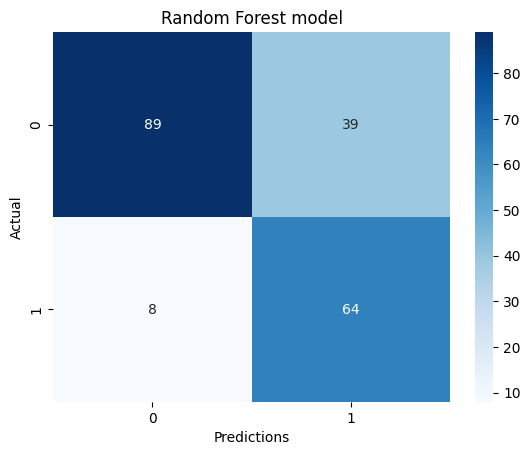

In [77]:
cm = confusion_matrix(forest_y, y_test)
sns.heatmap(cm, annot=True, cmap="Blues")
plt.title('Random Forest model')
plt.xlabel('Predictions')
plt.ylabel('Actual')
plt.show()

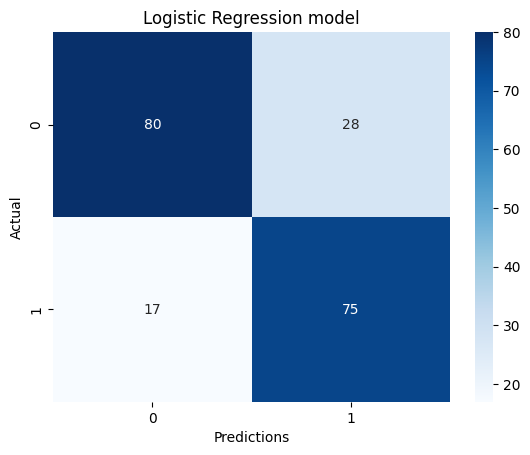

In [79]:
cm = confusion_matrix(logistic_y, y_test)
sns.heatmap(cm, annot=True, cmap="Blues")
plt.title('Logistic Regression model')
plt.xlabel('Predictions')
plt.ylabel('Actual')
plt.show()

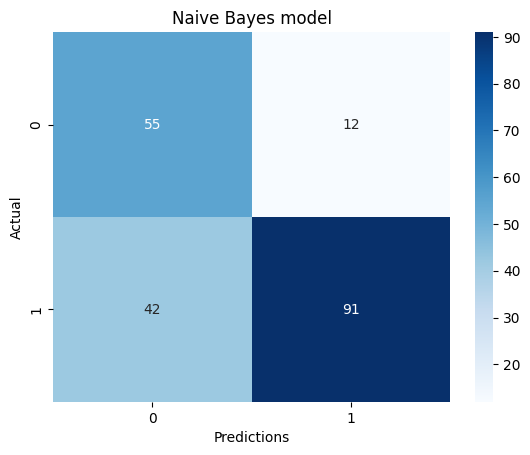

In [80]:
cm = confusion_matrix(naive_y, y_test)
sns.heatmap(cm, annot=True, cmap="Blues")
plt.title('Naive Bayes model')
plt.xlabel('Predictions')
plt.ylabel('Actual')
plt.show()

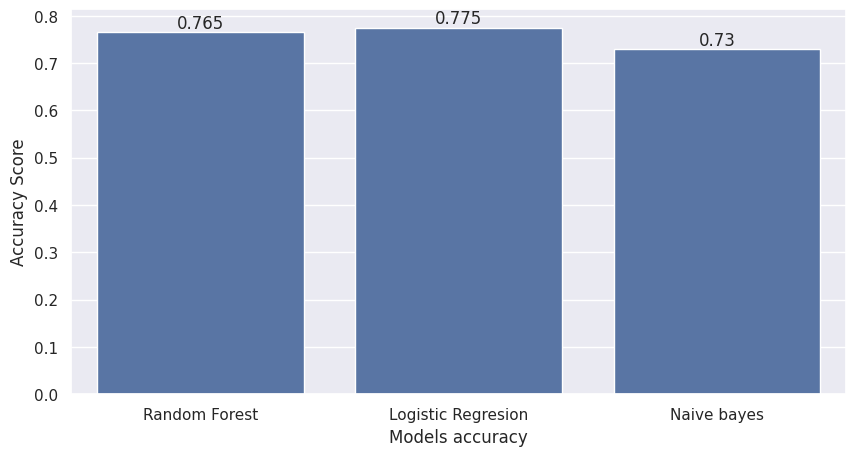

In [94]:
acc_forest = accuracy_score(forest_y, y_test)
acc_logistic = accuracy_score(logistic_y, y_test)
acc_naive =  accuracy_score(naive_y, y_test)
plt.subplots(figsize=(10, 5))
sns.set_theme()
ax = sns.barplot(y=[acc_forest, acc_logistic, acc_naive], x=["Random Forest", "Logistic Regresion", "Naive bayes"])
ax.bar_label(ax.containers[0])
plt.xlabel('Models accuracy')
plt.ylabel('Accuracy Score')
plt.show()